In [1]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = "4"

In [54]:
wa_dir = "/data8/anushkapa/heatmaps/hists/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/whatsapp"
og_dir = "/data8/anushkapa/heatmaps/hists/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/original"

In [73]:
wan_dir = "/data8/anushkapa/heatmaps/norm/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/whatsapp"
ogn_dir = "/data8/anushkapa/heatmaps/norm/Pne_Nor_Cov_baseline-lr:0.001-wd:0.0_balmy-wildflower-378/original"

In [55]:
wa_act_files = [f for f in os.listdir(wa_dir) if 'activations' in f and f.endswith('.pt')] 
og_act_files = [f for f in os.listdir(og_dir) if 'activations' in f and f.endswith('.pt')] 

In [74]:
wan_act_files = [f for f in os.listdir(wan_dir) if 'activations' in f and f.endswith('.pt')] 
ogn_act_files = [f for f in os.listdir(ogn_dir) if 'activations' in f and f.endswith('.pt')] 

In [56]:
wa_grad_files = [f for f in os.listdir(wa_dir) if 'gradients' in f and f.endswith('.pt')] 
og_grad_files = [f for f in os.listdir(og_dir) if 'gradients' in f and f.endswith('.pt')] 

In [75]:
wan_grad_files = [f for f in os.listdir(wan_dir) if 'gradients' in f and f.endswith('.pt')] 
ogn_grad_files = [f for f in os.listdir(ogn_dir) if 'gradients' in f and f.endswith('.pt')] 

In [57]:
len(wa_act_files), len(og_act_files), len(wa_grad_files), len(og_grad_files)

(113, 113, 117, 117)

In [76]:
len(wan_act_files), len(ogn_act_files), len(wan_grad_files), len(ogn_grad_files)

(281, 281, 286, 287)

In [58]:
wa_grad_tensors = []
og_grad_tensors = []
for file in wa_grad_files:
    wa_grad_tensors.append(torch.load(os.path.join(wa_dir, file)))
for file in og_grad_files:
    og_grad_tensors.append(torch.load(os.path.join(og_dir, file)))

wa_grad = torch.stack(wa_grad_tensors)
og_grad = torch.stack(og_grad_tensors)

In [77]:
wan_grad_tensors = []
ogn_grad_tensors = []
for file in wan_grad_files:
    wan_grad_tensors.append(torch.load(os.path.join(wan_dir, file)))
for file in ogn_grad_files:
    ogn_grad_tensors.append(torch.load(os.path.join(ogn_dir, file)))

wan_grad = torch.stack(wan_grad_tensors)
ogn_grad = torch.stack(ogn_grad_tensors)

In [59]:
wa_act_tensors = []
og_act_tensors = []
for file in wa_act_files:
    wa_act_tensors.append(torch.load(os.path.join(wa_dir, file)))
for file in og_act_files:
    og_act_tensors.append(torch.load(os.path.join(og_dir, file)))

wa_act = torch.stack(wa_act_tensors)
og_act = torch.stack(og_grad_tensors)

In [78]:
wan_act_tensors = []
ogn_act_tensors = []
for file in wan_act_files:
    wan_act_tensors.append(torch.load(os.path.join(wan_dir, file)))
for file in ogn_act_files:
    ogn_act_tensors.append(torch.load(os.path.join(ogn_dir, file)))

wan_act = torch.stack(wan_act_tensors)
ogn_act = torch.stack(ogn_grad_tensors)

In [79]:
wan_act.shape, og_act.shape, wa_grad.shape, og_grad.shape

(torch.Size([281, 1, 512, 64, 64]),
 torch.Size([117, 1, 512, 64, 64]),
 torch.Size([117, 512, 64, 64]),
 torch.Size([117, 512, 64, 64]))

In [80]:
count =0 
for t in wan_act.squeeze(1):
    if t.sum() == 0:
        count +=1
count

281

In [63]:
wa_grad = wa_grad.squeeze(1)
og_grad = og_grad.squeeze(1)

In [64]:
a = wa_grad[55].resize(512,64*64)
b = og_grad[55].resize(512,64*64)

/data5/home/anushkapa/.local/lib/python3.8/site-packages/torch/_tensor.py:586: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


In [65]:
a.shape, b.shape

(torch.Size([512, 4096]), torch.Size([512, 4096]))

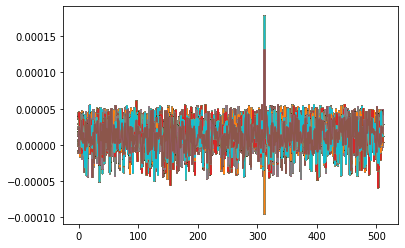

In [67]:
plt.plot(a.detach().cpu().numpy())
plt.show()

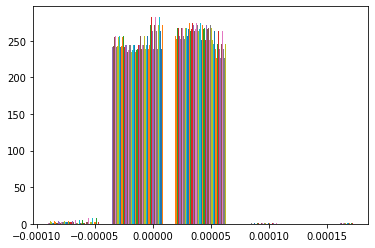

In [70]:
plt.hist(a.detach().cpu().numpy(),bins=5)
plt.show()

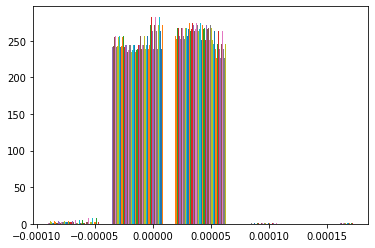

In [71]:
plt.hist(b.detach().cpu().numpy(),bins=5)
plt.show()

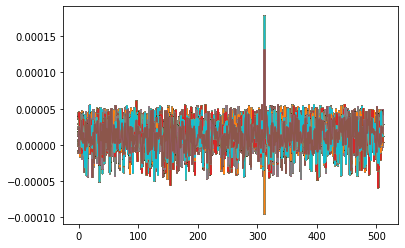

In [68]:
plt.plot(b.detach().cpu().numpy())
plt.show()

In [85]:
cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
cos(a,b)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 

In [82]:
wan_grad = wan_grad.squeeze(1)
ogn_grad = ogn_grad.squeeze(1)
an = wan_grad[55].resize(512,64*64)
bn = ogn_grad[55].resize(512,64*64)

/data5/home/anushkapa/.local/lib/python3.8/site-packages/torch/_tensor.py:586: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


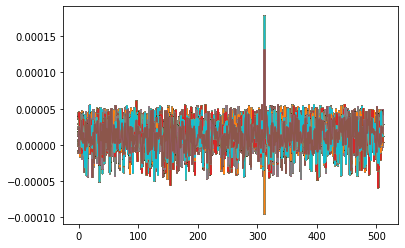

In [87]:
plt.plot(an.detach().cpu().numpy())
plt.show()

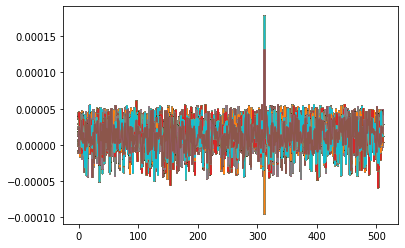

In [88]:
plt.plot(bn.detach().cpu().numpy())
plt.show()

In [89]:
cos(bn,b)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 